In [2]:
import numpy as np
from scipy import stats
from sys import getsizeof
import matplotlib.pyplot as plt
from model_utils import *

In [21]:
arr = np.load('Results/cifar_dae_pc_stability_consecutive_angles.npy', allow_pickle=True)
print(arr)

[[[ 1.04903841  1.93613541 88.67925262 ...  1.76125312  1.62533975
    2.36057425]
  [ 1.31626093  5.90471649 84.707901   ... 81.89493561  5.5661273
    9.35884953]
  [ 1.90967345  6.71746731 41.6527977  ... 82.03104401  4.22317648
    7.92867661]
  ...
  [        nan         nan         nan ... 11.63038731 12.50509453
    5.07056808]
  [        nan         nan         nan ...  7.49729395 11.17385197
    9.52181625]
  [        nan         nan         nan ... 11.61716652 11.03465557
   10.09147644]]

 [[ 5.5211606  15.4737711  70.15541077 ...  1.50610185  4.17996645
    2.80686426]
  [ 4.7818017  15.18236732 88.92813873 ...  2.67305541  4.67642212
    2.93984771]
  [ 3.14254928  8.46886253 62.07807922 ...  1.91202927  3.14186406
    4.44496965]
  ...
  [        nan         nan         nan ...  4.75612831 11.43126869
   12.71620274]
  [        nan         nan         nan ...  6.85122919 12.86911011
   10.10296917]
  [        nan         nan         nan ...  5.34793377  5.33373404
    6.1

Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].


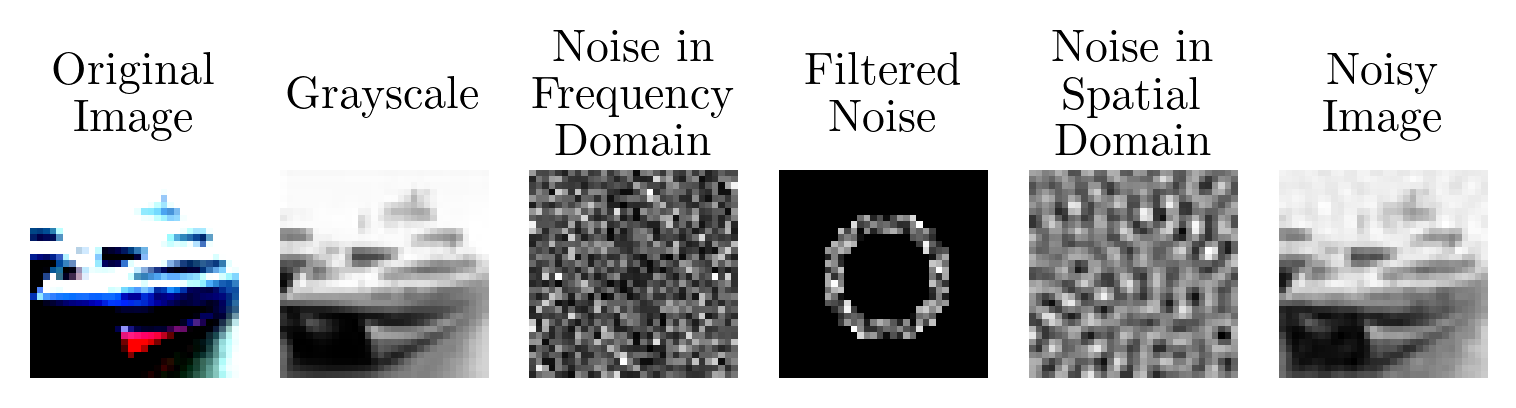

In [20]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern'],
    'font.size': 11,
    'axes.titlesize': 11
})

test_images, _ = load_cifar_list()
img = test_images[1]
img = np.transpose(img, (1, 2, 0))
img_gray = 0.2989 * img[:,:,0] + 0.5870 * img[:,:,1] + 0.1140 * img[:,:,2]

sample_image = img_gray
noise_level = 0.25
circle_mask = draw_circle(shape=sample_image.shape, diameter=7)
outer_circle_mask = draw_circle(shape=sample_image.shape, diameter=10)
ring_mask = outer_circle_mask & ~circle_mask

noise = np.random.randn(*sample_image.shape)
noise_fft = np.fft.fftshift(np.fft.fft2(noise))
noise_fft_ring = noise_fft * ring_mask * noise_level
frequency_noise = np.fft.ifft2(np.fft.ifftshift(noise_fft_ring))

noisy_img = sample_image + np.real(frequency_noise)

fig, axes = plt.subplots(1, 6, figsize=(6.266, 3), dpi=300)

# Plot the images
axes[0].imshow(img)
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].axis('off')

axes[2].imshow(np.abs(noise_fft), cmap='gray')
axes[2].axis('off')

axes[3].imshow(np.abs(noise_fft_ring), cmap='gray')
axes[3].axis('off')

axes[4].imshow(np.real(frequency_noise), cmap='gray')
axes[4].axis('off')

axes[5].imshow(noisy_img, cmap='gray')
axes[5].axis('off')

titles = [
    'Original\nImage',
    'Grayscale',
    'Noise in\nFrequency\nDomain',
    'Filtered\nNoise',  
    'Noise in\nSpatial\nDomain',
    'Noisy\nImage'
]

for i, title in enumerate(titles):
    axes[i].text(
        0.5, 1.35,
        title,
        ha='center',
        va='center',
        transform=axes[i].transAxes,
        fontsize=11,
    )

plt.savefig('Results/figures/pdf/adding_frequency_noise_approach.pdf', bbox_inches='tight')
plt.show()

In [12]:
accuracyarray = np.load('Results/cifar_avg_frequency_classification.npy', allow_pickle=True)
stdarray = np.load('Results/cifar_std_frequency_classification.npy', allow_pickle=True)

In [17]:
accuracyarray.item()

{'sae_clean_acc': 0.39776666666666666,
 'dae_clean_acc': 0.40526666666666666,
 'sae_low_freq_acc': 0.1523,
 'dae_low_freq_acc': 0.1457,
 'sae_mid_freq_acc': 0.16893333333333335,
 'dae_mid_freq_acc': 0.14196666666666669,
 'sae_high_freq_acc': 0.251,
 'dae_high_freq_acc': 0.22456666666666666}

In [15]:
cifar_size_ls = [6,   6,   6,   6,   6,   6,    # 6
                10,  10,  10,  10,  10,  10,    # 6
                16,  16,  16,  16,  16,  16,    # 6
                28,  28,  28,  28,  28,  28,    # 6
                48,  48,  48,  48,  48,  48,  48,  48, 48, # 9
                90,  90,  90,  90,  90,  90,  90,  90,  90,  90, #10
                128, 128, 128, 128, 128, 128, 128, 128, 128, 128,
                128, 128, 128, 128, 128, 128, 128 # 17
                ]

print(cifar_size_ls[42])

90


In [17]:
import numpy as np
a = np.load('Results/cifar_sae_rfs.npy')
a.shape

(2, 60, 128, 3, 32, 32)

In [ ]:
def load_and_print_pvalues(dataset="mnist"):
    """
    Load results and print p-values for each noise type.
    
    Args:
        dataset: Dataset name ('mnist' or 'cifar')
    """
    # Load all individual results (not just averages)
    all_results_file = f"Results/{dataset}_all_frequency_classification.npy"
    try:
        all_results = np.load(all_results_file, allow_pickle=True).item()
    except FileNotFoundError:
        print(f"Error: Could not find {all_results_file}")
        print("Make sure you've run the main script to generate all results.")
        return
    
    # Calculate p-values for each noise type using arrays of individual measurements
    # Clean images
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_clean_acc'],
        all_results['dae_clean_acc']
    )
    print(f"{dataset} - Clean images p-value: {p_value:.6f}")
    
    # Low frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_low_freq_acc'],
        all_results['dae_low_freq_acc']
    )
    print(f"{dataset} - Low frequency noise p-value: {p_value:.6f}")
    
    # Mid frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_mid_freq_acc'],
        all_results['dae_mid_freq_acc']
    )
    print(f"{dataset} - Mid frequency noise p-value: {p_value:.6f}")
    
    # High frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_high_freq_acc'],
        all_results['dae_high_freq_acc']
    )
    print(f"{dataset} - High frequency noise p-value: {p_value:.6f}")

load_and_print_pvalues("mnist")
load_and_print_pvalues("cifar")

cifar - Clean images p-value: 0.048904
cifar - Low frequency noise p-value: 0.215978
cifar - Mid frequency noise p-value: 0.706358
cifar - High frequency noise p-value: 0.049458


In [1]:
from model_utils import *
load_conv_model(f"/home/david/cifar_models/dae/0", 'dae', 59)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=1024, out_features=128, bias=True)
  )
  (linear): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1,

In [37]:
# change shape from:  (num_models, num_neurons, num_epochs, color, width, height) to (num_models, num_epochs, num_neurons, width*height)
myarray = np.moveaxis(myarray, 2, 1).reshape(myarray.shape[0], myarray.shape[2], myarray.shape[1], myarray.shape[3], myarray.shape[4]*myarray.shape[5])
# make [-1] and [-2] into one dimension with multiplication
myarray.shape

(1, 1, 128, 3, 1024)

In [15]:

print(myarray.shape)

(1, 128, 1, 3, 32, 32)


In [20]:
print(myarray.shape)
myarray = myarray.squeeze()
print(myarray.shape)
# find the size of the array in megabytes
print(getsizeof(myarray) / 1024 / 1024)

(128, 1, 3, 32, 32)
(128, 3, 32, 32)
0.000152587890625


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-36.55162..42.617615].


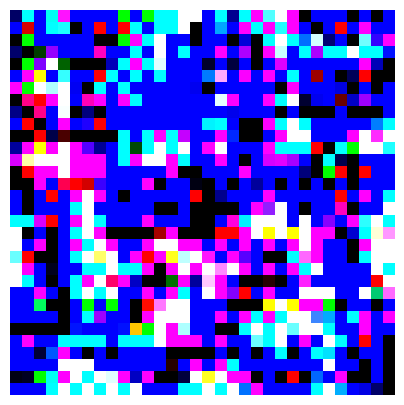

In [19]:
import numpy as np
import matplotlib.pyplot as plt

first_image = np.transpose(myarray[127, 0, :, :, :], (1, 2, 0))

plt.figure(figsize=(5, 5))
plt.imshow(first_image)
plt.axis('off')
plt.show()
